Mounting Google Drive
This is a step followed by me, if you are running in your system please have the following folder in this order "ENPM673/project_1/"

In [1]:
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


In [2]:
path_to_folder = "ENPM673/"
%cd /content/drive/My\ Drive/{path_to_folder}

/content/drive/My Drive/ENPM673


Importing Directories
This code imports essential libraries for image processing and visualization, including OpenCV for image manipulation, NumPy for numerical operations, Matplotlib for plotting, and Google Colab's custom patch for displaying images.

In [3]:
# Importing Dependencies
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
from google.colab.patches import cv2_imshow  # For compatibility with Colab


# cv2.imshow()
from google.colab.patches import cv2_imshow

Paths for the video and the folder to save every frame created

In [4]:
path_to_folder = "ENPM673/"
%cd /content/drive/My\ Drive/{path_to_folder}

video_path = "project_1/object_tracking.mp4"
frames_folder = "project_1/frames/"
video = cv.VideoCapture(video_path)
currentframe = 0

/content/drive/My Drive/ENPM673


If condition to check the video opened or not

In [5]:
# Check if the video is opened successfully
if not video.isOpened():
    print("Error: Could not open the video.")
    exit()

This script processes a video frame-by-frame to track and visualize the movement of a dark object. It identifies the object's centroid by detecting dark pixels and calculating their average position. The centroid positions are stored and used to draw a trajectory on the video, with a green line indicating the past movement and a red dot marking the current position. The modified frames are saved into a new video file, showing the object's motion path over time

In [19]:
# Open the video file
video = cv.VideoCapture("project_1/object_tracking.mp4")

# Get the video properties
fps = int(video.get(cv.CAP_PROP_FPS))
frame_width = int(video.get(cv.CAP_PROP_FRAME_WIDTH))
frame_height = int(video.get(cv.CAP_PROP_FRAME_HEIGHT))

# Define the codec and create VideoWriter object
output_video = cv.VideoWriter("project_1/output_video.mp4",
                              cv.VideoWriter_fourcc(*'mp4v'),
                              fps,
                              (frame_width, frame_height))

# Store trajectory points
trajectory = []

while True:
    # Read a frame from the video
    success, frame = video.read()

    # Check if frame reading was successful
    if not success:
        break

    # Get the coordinates of dark pixels
    dark_pixel = np.where(np.all(frame < 30, axis=-1))

    # Extract x and y values of dark pixels
    x_values = dark_pixel[1]
    y_values = dark_pixel[0]

    # Calculate the centroid
    if len(x_values) > 0 and len(y_values) > 0:
        mean_x = int(np.mean(x_values))
        mean_y = int(np.mean(y_values))
        trajectory.append((mean_x, mean_y))

    # Draw the trajectory on the frame
    for i in range(1, len(trajectory)):
        cv.line(frame, trajectory[i - 1], trajectory[i], (0, 255, 0), 2)

    # Draw the latest centroid
    if len(trajectory) > 0:
        cv.circle(frame, trajectory[-1], 5, (0, 0, 255), -1)

    # Write the modified frame to the output video
    output_video.write(frame)

    # Check for 'q' key press to exit
    if cv.waitKey(32) & 0xFF == ord('q'):
        break

# Release resources
video.release()
output_video.release()
cv.destroyAllWindows()


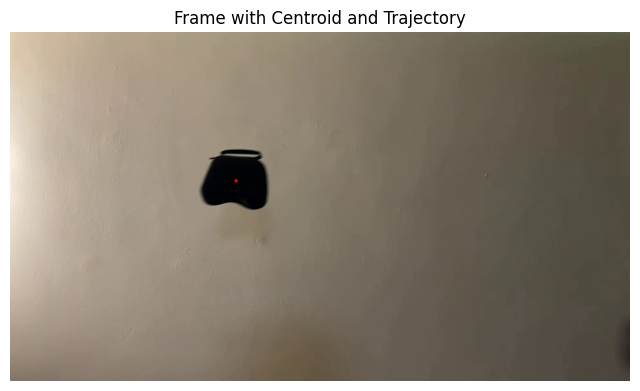

In [20]:
# Define the path to the image
image_path = "project_1/frames/frame_400.jpg"  # Change to the desired frame

# Load the image
image = cv.imread(image_path)

# Convert BGR to RGB for correct color representation
image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# Process the image to find dark pixels
dark_pixel = np.where(np.all(image < 30, axis=-1))

# Extract x and y values of dark pixels
x_values = dark_pixel[1]
y_values = dark_pixel[0]

# Calculate the centroid
if len(x_values) > 0 and len(y_values) > 0:
    mean_x = int(np.mean(x_values))
    mean_y = int(np.mean(y_values))

    # Draw the centroid (red dot)
    cv.circle(image_rgb, (mean_x, mean_y), 5, (255, 0, 0), -1)

    # Store trajectory points (This should be cumulative across frames in your main script)
    trajectory = [(mean_x, mean_y)]  # Replace with the actual trajectory list

    # Draw the trajectory (green line)
    for i in range(1, len(trajectory)):
        cv.line(image_rgb, trajectory[i - 1], trajectory[i], (0, 255, 0), 2)

# Display the image with the centroid and trajectory
plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Frame with Centroid and Trajectory")
plt.show()
